In [32]:
from matplotlib import pyplot as plt
from bs4 import BeautifulSoup
from collections import defaultdict, Counter
from typing import List, Dict, Tuple
import re
import requests
import random
import tqdm

In [33]:
data = [ ("big data", 100, 15), ("Hadoop", 95, 25), ("Python", 75, 50), ("R", 50, 40), ("machine learning", 80, 20), ("statistics", 20, 60), ("data science", 60, 70), ("analytics", 90, 3),("team player", 85, 85), ("dynamic", 2, 90), ("synergies", 70, 0), ("actionable insights", 40, 30), ("think out of the box", 45, 10),("self-starter", 30, 50), ("customer focus", 65, 15), ("thought leadership", 35, 35)]

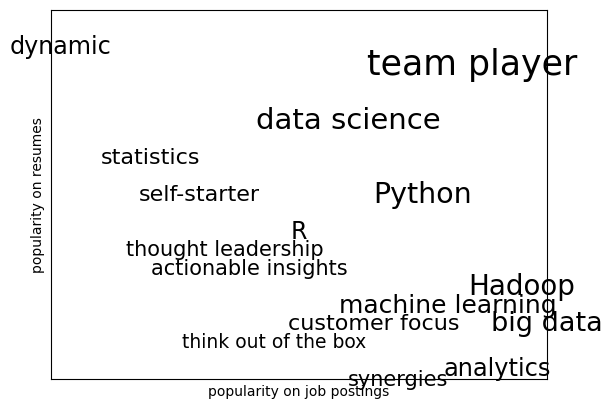

In [34]:
def text_size(total: int) -> float:
    """Es igual a 8 si el total es 0, 28 si el total es 200"""
    return 8 + total / 200 * 20

for word, job_popularity, resume_popularity in data:
    plt.text(job_popularity, resume_popularity, word, ha='center', va='center', size=text_size(job_popularity + resume_popularity))

plt.xlabel("popularity on job postings")
plt.ylabel("popularity on resumes")
plt.axis([0, 100, 0, 100])
plt.xticks([])
plt.yticks([])
plt.show()

## modelos de lenguaje n-Gram

In [35]:
def fix_unicode(text: str) -> str:
    # Sustituye caracteres unicode problemáticos por espacios o texto plano
    return text.replace(u"\u2019", "'").replace(u"\u201c", '"').replace(u"\u201d", '"')

In [36]:
def get_document():
    url = "http://radar.oreilly.com/2010/06/what-is-data-science.html"
    
    # Añadimos un "User-Agent" para que el sitio no bloquee la petición
    headers = {"User-Agent": "Mozilla/5.0"}
    html = requests.get(url, headers=headers).text
    soup = BeautifulSoup(html, 'html5lib')

    # Intentamos encontrar el artículo de forma más genérica
    content = soup.find("article") or soup.find("div", class_="article-body") or soup.find("main")
    
    if content is None:
        # Si falla el scraping, usamos un texto de respaldo para que puedas seguir
        print("No se pudo scrapear el sitio. Usando texto de prueba...")
        return ["data", "science", "is", "about", "data", "."]

    regex = r"[\w']+|[\.]"
    document = []

    # Usamos .find_all('p') que es más explícito y seguro
    for paragraph in content.find_all("p"):
        words = re.findall(regex, fix_unicode(paragraph.text))
        document.extend(words)

    return document

def get_document_local():
    texto_ejemplo = """
    Data science is the future. Data science uses data to 
    predict data. A data scientist is a person who knows data.
    """
    regex = r"[\w']+|[\.]"
    return re.findall(regex, texto_ejemplo.lower())

# Prueba esto si el scraper sigue fallando
document = get_document_local()

In [37]:
document = get_document()

transitions = defaultdict(list)

for prev, current in zip(document, document[1:]):
    transitions[prev].append(current)

No se pudo scrapear el sitio. Usando texto de prueba...


In [38]:
def generate_using_bigrams() -> str:
    current = "." 
    result = []

    while True:
        next_word_candidates = transitions[current]
        
        # VALIDACIÓN: Si la lista está vacía, no podemos elegir.
        if not next_word_candidates:
            # Si no hay nada que siga al punto, terminamos o 
            # devolvemos lo que tengamos hasta ahora.
            return " ".join(result) if result else "No hay transiciones."

        current = random.choice(next_word_candidates)
        result.append(current)
        
        # Si la palabra elegida es un punto, cerramos la oración.
        if current == ".": 
            return " ".join(result)

print(generate_using_bigrams())

No hay transiciones.


In [39]:
trigrams_transitions = defaultdict(list)
starts = []
for prev, current, next in zip(document, document[1:], document[2:]):
    if prev == '.':
        starts.append(current)
    trigrams_transitions[(prev, current)].append(next)

In [40]:
def generate_using_trigrams() -> str:
    current = random.choice(starts)
    prev = "."
    result = [current]

    while True:
        next_word_candidates = trigrams_transitions[(prev, current)]
        next_word = random.choise(next_word_candidates)
        prev, current = current, next_word
        result.append(current)
        if current == ".":
            return " ".join(result)

In [41]:
# escribe un alias para referirse luego a las gramaticas
Grammar = Dict[str, List[str]]
grammar = {"_S" : ["_NP _VP"],"_NP" : ["_N","_A _NP _P _A _N"],"_VP" : ["_V","_V _NP"],"_N" : ["data science", "Python", "regression"],"_A" : ["big", "linear", "logistic"],"_P" : ["about", "near"],"_V" : ["learns", "trains", "tests", "is"]}

In [42]:
def is_terminal(token: str) -> bool:
    return token[0] != "_"

In [43]:
def expand(grammar: Grammar, tokens: List[str]) -> List[str]:
    for i, token in enumerate(tokens):
        # si es un elemento terminal, lo salta
        if is_terminal(token): continue
        # si no, es un elemento no terminal, y hay que elegir un sustituto aleatoriamente
        replacement = random.choices(grammar[token])
        if is_terminal(replacement):
            tokens[i] = replacement
        else:
            # el sustituto puede ser, p.ej., "NP_ _VP", asi hay que dividirlo en espacios y unirlo
            tokens = token[:i] + replacement.split() + tokens[(i + 1):]
        # ahora usa expand en la nueva lista de elementos
        return expand(grammar, tokens)
    # si llegamos aqui, teniamos todos los terminales, asi que esta hecho
    return tokens

In [44]:
def generate_sentences(grammar: Grammar) -> List[str]:
    return expand(grammar, ["_S"])

## muestreo de Gibbs

In [45]:
def roll_a_die():
    return random.choice([1,2,3,4,5,6])

def direct_sample():
    d1 = roll_a_die()
    d2 = roll_a_die()
    return d1, d1 + d2

def random_y_given_x(x):
    """equally likely to be x + 1, x + 2, ... , x + 6"""
    return x + roll_a_die()

def random_x_given_y(y):
    if y <= 7:
        # if the total is 7 or less, the first die is equally likely to be
        # 1, 2, ..., (total - 1)
        return random.randrange(1, y)
    else:
        # if the total is 7 or more, the first die is equally likely to be
        # (total - 6), (total - 5), ..., 6
        return random.randrange(y - 6, 7)

def gibbs_sample(num_iters=100):
    x, y = 1, 2 # doesn't really matter
    for _ in range(num_iters):
        x = random_x_given_y(y)
        y = random_y_given_x(x)
    return x, y

def compare_distributions(num_samples=1000):
    counts = defaultdict(lambda: [0, 0])
    for _ in range(num_samples):
        counts[gibbs_sample()][0] += 1
        counts[direct_sample()][1] += 1
    return counts

## modelos de temas

In [46]:
def sample_from(weights: List[float]) -> int:
    """Retornos i con ponderaciones de probabilidad[i] / sum(pesos)"""
    total = sum(weights)
    rnd = total * random.random()
    for i, w in enumerate(weights):
        rnd -= w
        if rnd <= 0: return i

In [47]:
# tirar 1000 veces y cuenta
draws = Counter(sample_from([0.1, 0.1, 0.8]) for _ in range(1000))
assert 10 < draws[0] < 190 # debería ser ~10%, es una prueba muy floja
assert 10 < draws[1] < 190 # debería ser ~10%, es una prueba muy floja
assert 650 < draws[2] < 950 # debería ser ~80%, es una prueba muy floja
assert draws[0] + draws[1] + draws[2] == 1000

In [48]:
documents = [
    ["Hadoop", "Big Data", "HBase", "Java", "Spark", "Storm", "Cassandra"],
    ["NoSQL", "MongoDB", "Cassandra", "HBase", "Postgres"],
    ["Python", "scikit-learn", "scipy", "numpy", "statsmodels", "pandas"],
    ["R", "Python", "statistics", "regression", "probability"],
    ["machine learning", "regression", "decision trees", "libsvm"],
    ["Python", "R", "Java", "C++", "Haskell", "programming languages"],
    ["statistics", "probability", "mathematics", "theory"],
    ["machine learning", "scikit-learn", "Mahout", "neural networks"],
    ["neural networks", "deep learning", "Big Data", "artificial intelligence"],
    ["Hadoop", "Java", "MapReduce", "Big Data"],
    ["statistics", "R", "statsmodels"],
    ["C++", "deep learning", "artificial intelligence", "probability"],
    ["pandas", "R", "Python"],
    ["databases", "HBase", "Postgres", "MySQL", "MongoDB"],
    ["libsvm", "regression", "support vector machines"]
]

In [49]:
K = 4

In [50]:
# una lista de Counter, uno por cada documento
document_topic_counts = [Counter() for _ in documents]

# una lista de Counter, uno por cada tema
topic_word_counts = [Counter() for _ in range(K)]

# una lista de numeros, uno por cada tema
topic_counts = [0 for _ in range(K)]

# una lista de numeros, uno por cada documento
document_lengths = [len(document) for document in documents]

# el numero de plalabras distintas
distinct_words = set(word for document in documents for word in document)
W = len(distinct_words)

# el numero de documentos distintos
D = len(documents)

In [51]:
document_topic_counts[3][1]

0

In [52]:
topic_word_counts[2]["nlp"]

0

In [53]:
def p_topic_given_document(topic: int, d: int, alpha: float = 0.1) -> float:
    """La fracción de palabras en el documento «d» Que se asignan a 'topic' (más un poco de suavizado)"""
    return ((document_topic_counts[d][topic] + alpha) / (document_lengths[d] + K * alpha))

def p_word_given_topic(word: str, topic: int, beta: float = 0.1) -> float:
    """La fracción de palabras asignadas a 'tema' que igual ‘palabra’ (más un poco de suavizado)"""
    return ((topic_word_counts[topic][word] + beta) / (topic_counts[topic] + W * beta))


In [54]:
def topic_weight(d: int, word: str, k: int) -> float:
    """Given a document and a word in that document, return the weight for the kth topic"""
    return p_word_given_topic(word, k) * p_topic_given_document(k, d)

def choose_new_topic(d: int, word: str) -> int:
    return sample_from([topic_weight(d, word, k) for k in range(K)])

In [55]:
random.seed(0)
document_topics = [[random.randrange(K) for word in document] for document in documents]
for d in range(D):
    for word, topic in zip(documents[d], document_topics[d]):
        document_topic_counts[d][topic] +=1
        topic_word_counts[topic][word] += 1
        topic_counts[topic] +=1

In [56]:
for iter in tqdm.trange(1000):
    for d in range(D):
        for i, (word, topic) in enumerate(zip(documents[d],document_topics[d])):
            # quita esta plabra / tema de los recuentos de modo que no influya en los pesos
            document_topic_counts[d][topic] -=1
            topic_word_counts[topic][word] -= 1
            topic_counts[topic] -= 1
            document_lengths[d] -= 1
            # elige un nuevo tema basado en los pesos
            new_topic = choose_new_topic(d, word)
            document_topics[d][i] = new_topic
            # y ahora lo aniade de nuevo a los recuentos 
            document_topic_counts[d][new_topic] += 1
            topic_word_counts[new_topic][word] += 1
            topic_counts[new_topic] += 1
            document_lengths[d] += 1

100%|██████████| 1000/1000 [00:00<00:00, 1858.30it/s]


In [57]:
for k, word_counts in enumerate(topic_word_counts):
    for word, count in word_counts.most_common():
        if count > 0:
            print(k, word, count)

0 Java 3
0 Big Data 3
0 Hadoop 2
0 HBase 1
0 C++ 1
0 Spark 1
0 Storm 1
0 programming languages 1
0 MapReduce 1
0 Cassandra 1
0 deep learning 1
1 HBase 2
1 neural networks 2
1 Postgres 2
1 MongoDB 2
1 machine learning 2
1 Cassandra 1
1 numpy 1
1 decision trees 1
1 deep learning 1
1 databases 1
1 MySQL 1
1 NoSQL 1
1 artificial intelligence 1
1 scipy 1
2 regression 3
2 Python 2
2 R 2
2 libsvm 2
2 scikit-learn 2
2 mathematics 1
2 support vector machines 1
2 Haskell 1
2 Mahout 1
3 statistics 3
3 probability 3
3 Python 2
3 R 2
3 pandas 2
3 statsmodels 2
3 C++ 1
3 artificial intelligence 1
3 theory 1


In [58]:
topic_names = ["Big Data and programming languages", "Python and statistics", "databases", "machine learning"]

In [59]:
for document, topic_counts in zip(documents, document_topic_counts):
    print(document)
    for topic, count in topic_counts.most_common():
        if count > 0:
            print(topic_names[topic], count)
        print()

['Hadoop', 'Big Data', 'HBase', 'Java', 'Spark', 'Storm', 'Cassandra']
Big Data and programming languages 7




['NoSQL', 'MongoDB', 'Cassandra', 'HBase', 'Postgres']
Python and statistics 5




['Python', 'scikit-learn', 'scipy', 'numpy', 'statsmodels', 'pandas']
Python and statistics 2

databases 2

machine learning 2


['R', 'Python', 'statistics', 'regression', 'probability']
machine learning 3

databases 2



['machine learning', 'regression', 'decision trees', 'libsvm']
databases 2

Python and statistics 2



['Python', 'R', 'Java', 'C++', 'Haskell', 'programming languages']
databases 3

Big Data and programming languages 3



['statistics', 'probability', 'mathematics', 'theory']
machine learning 3

databases 1



['machine learning', 'scikit-learn', 'Mahout', 'neural networks']
databases 2

Python and statistics 2



['neural networks', 'deep learning', 'Big Data', 'artificial intelligence']
Python and statistics 3

Big Data and programming languages 1



['Hadoop', 'Java', 'Ma